In [1]:
import adi
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.signal import butter,filtfilt

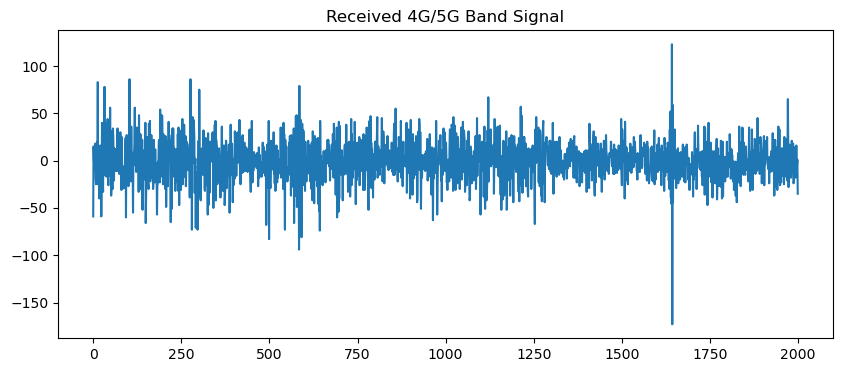

In [19]:
sdr = adi.Pluto()

sdr.sample_rate = int(2e6)

sdr.rx_lo = int(2.3e9)

sdr.rx_buffer_size = 65536

sdr.gain_control_mode = "slow_attack"

samples = sdr.rx()

received_signal = np.real(samples)

plt.figure(figsize=(10,4))

plt.plot(received_signal[:2000])

plt.title("Received 4G/5G Band Signal")

plt.show()

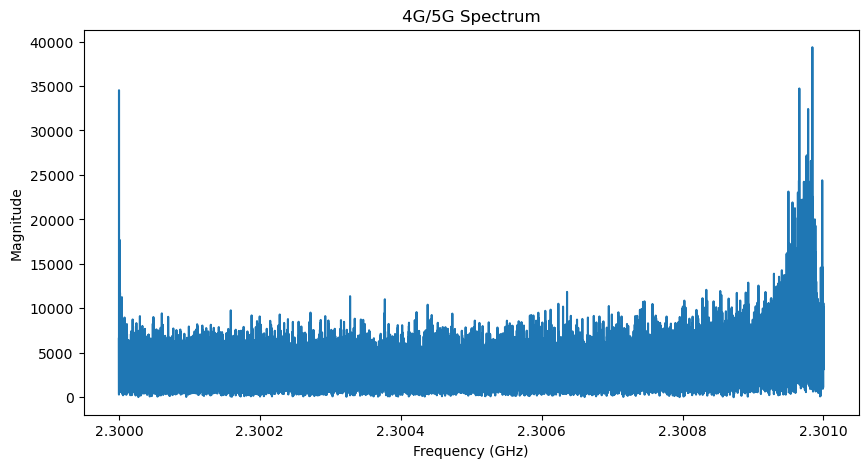

In [20]:
fft_output = np.fft.fft(received_signal)

freq = np.fft.fftfreq(len(received_signal),1/sdr.sample_rate)

mask = freq >= 0

freq = freq[mask]

magnitude = np.abs(fft_output[mask])

rf_freq = freq + sdr.rx_lo


plt.figure(figsize=(10,5))

plt.plot(rf_freq/1e9,magnitude)

plt.title("4G/5G Spectrum")

plt.xlabel("Frequency (GHz)")

plt.ylabel("Magnitude")

plt.show()

In [21]:
noise_floor = np.mean(magnitude)

print("Noise floor:",noise_floor)

Noise floor: 3521.0813159777367


In [22]:
threshold = noise_floor*3

peaks,_ = find_peaks(magnitude,height=threshold)

detected_freq = rf_freq[peaks]

print("Detected Channels:")

for f in detected_freq:

    print(round(f/1e9,3),"GHz")

Detected Channels:
2.3 GHz
2.3 GHz
2.3 GHz
2.3 GHz
2.3 GHz
2.3 GHz
2.3 GHz
2.3 GHz
2.3 GHz
2.3 GHz
2.3 GHz
2.3 GHz
2.3 GHz
2.3 GHz
2.3 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2.301 GHz
2

In [27]:
peak_magnitudes = magnitude[peaks]

strongest_index = np.argmax(peak_magnitudes)

channel_freq = freq[peaks][strongest_index]

rf_channel = rf_freq[peaks][strongest_index]

print("Selected Channel:",rf_channel/1e9,"GHz")

Selected Channel: 2.300984250437561 GHz


In [24]:
# Channel bandwidth

bandwidth = 100000


low = max(1000, channel_freq - bandwidth)

high = min(sdr.sample_rate/2 - 1000, channel_freq + bandwidth)


nyquist = sdr.sample_rate/2

low = low/nyquist

high = high/nyquist


b,a = butter(4,[low,high],btype='band')

filtered_signal = filtfilt(b,a,received_signal)

In [25]:
channel_power = magnitude[peaks][strongest_index]

print("Channel strength:",channel_power)

Channel strength: 39358.16913468142


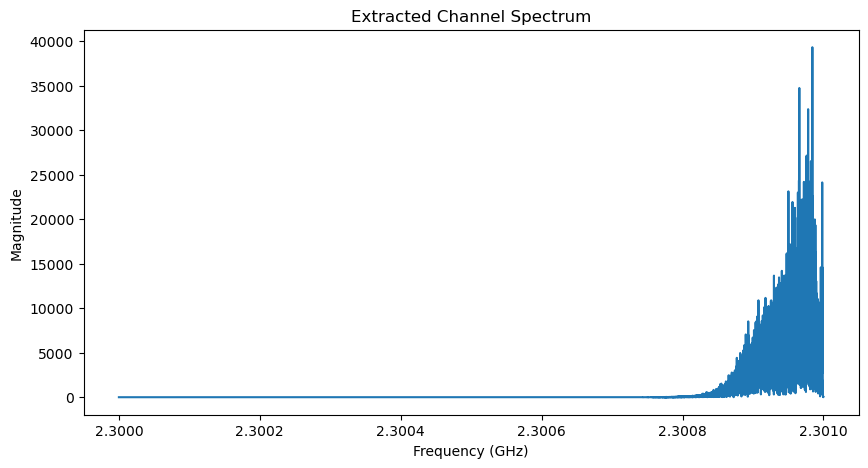

In [26]:
filtered_fft = np.fft.fft(filtered_signal)

filtered_mag = np.abs(filtered_fft[mask])


plt.figure(figsize=(10,5))

plt.plot(rf_freq/1e9,filtered_mag)

plt.title("Extracted Channel Spectrum")

plt.xlabel("Frequency (GHz)")

plt.ylabel("Magnitude")

plt.show()